In [39]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseOracleGate, grover_operator
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_distribution
import math

# Imports from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [40]:
def binary_states_to_oracle(binary_states: list[str]) -> PhaseOracleGate:
    """
    Converts a list of target binary strings into a single PhaseOracleGate 
    that marks all specified states.
    """
    if not binary_states:
        raise ValueError("The list of binary states cannot be empty.")
        
    # Determine number of qubits from the first state string
    num_qubits = len(binary_states[0])
    
    # Generate consistent variable names for little-endian ordering: ['v0', 'v1', ...]
    var_names = [f"v{i}" for i in range(num_qubits)]
    
    state_clauses = []
    
    for state in binary_states:
        if len(state) != num_qubits:
            raise ValueError("All binary strings must be of the same length.")
            
        # Reverse string to align with Qiskit's little-endian convention
        reversed_bits = list(reversed(state))
        
        # Build the AND clause for this specific state
        current_clause = []
        for bit, var in zip(reversed_bits, var_names):
            if bit == "1":
                current_clause.append(var)
            elif bit == "0":
                current_clause.append(f"~{var}")
            else:
                raise ValueError("Strings must contain only '0' or '1'.")
                
        # Join variables with '&' and wrap the state condition in parentheses
        state_clauses.append(f"({' & '.join(current_clause)})")
        
    # Combine all individual state clauses using the OR operator '|'
    full_expression = " | ".join(state_clauses)
    
    print(f"Target States: {binary_states}")
    print(f"Generated Multi-State Expression:\n{full_expression}\n")
    
    # Instantiate the gate with fixed variable ordering
    return PhaseOracleGate(full_expression, var_order=var_names)

# # --- Example Usage ---
# # Let's target two states: "001" and "101"
# targets = ["001", "101"]
# multi_oracle = multiple_binary_states_to_oracle(targets)

# print(f"Number of qubits: {multi_oracle.num_qubits}")

In [41]:
# 1. Select target state
marked_states = ["101101"]

In [42]:
# 2. Construct the Phase Oracle Gate
oracle_gate = binary_states_to_oracle(marked_states)
num_qubits = oracle_gate.num_qubits

Target States: ['101101']
Generated Multi-State Expression:
(v0 & ~v1 & v2 & v3 & ~v4 & v5)



In [43]:
# 3. Construct the Grover Operator (Oracle + Diffusion) using the gate
grover_op = grover_operator(oracle_gate)

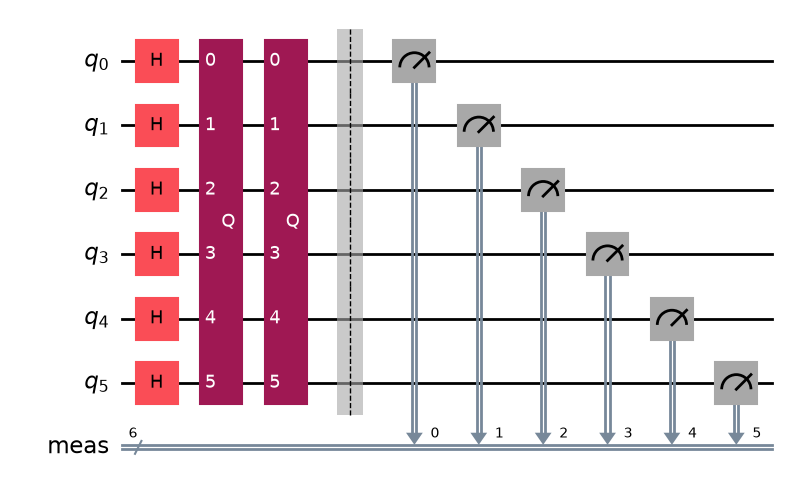

In [44]:
# 4. Assemble the complete Grover Search Circuit
# Number of optimal iterations for 3 qubits is approx. 2
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(num_qubits / 2**grover_op.num_qubits)))
)
grover_circuit = QuantumCircuit(num_qubits)

# Step A: State preparation (Equal superposition via Hadamard gates)
grover_circuit.h(range(num_qubits))

# Step B: Apply the Grover iteration loops
for _ in range(optimal_num_iterations):
    grover_circuit.append(grover_op, range(num_qubits))

# Step C: Measure all qubits
grover_circuit.measure_all()
grover_circuit.draw(output="mpl", style="iqp")

In [51]:
# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=3, layout_method="sabre", routing_method="sabre")

circuit_isa = pm.run(grover_circuit)
# circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")

sampler = Sampler(mode=backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.dynamical_decoupling.extra_slack_distribution = "middle"

sampler.options.default_shots = 10_000

sampler.options.twirling.enable_gates = True
sampler.options.twirling.enable_measure = True

In [52]:
# 5. Execute using modern Primitives (StatevectorSampler)
job = sampler.run([grover_circuit])

IBMInputValueError: 'The instruction h on qubits (0,) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'

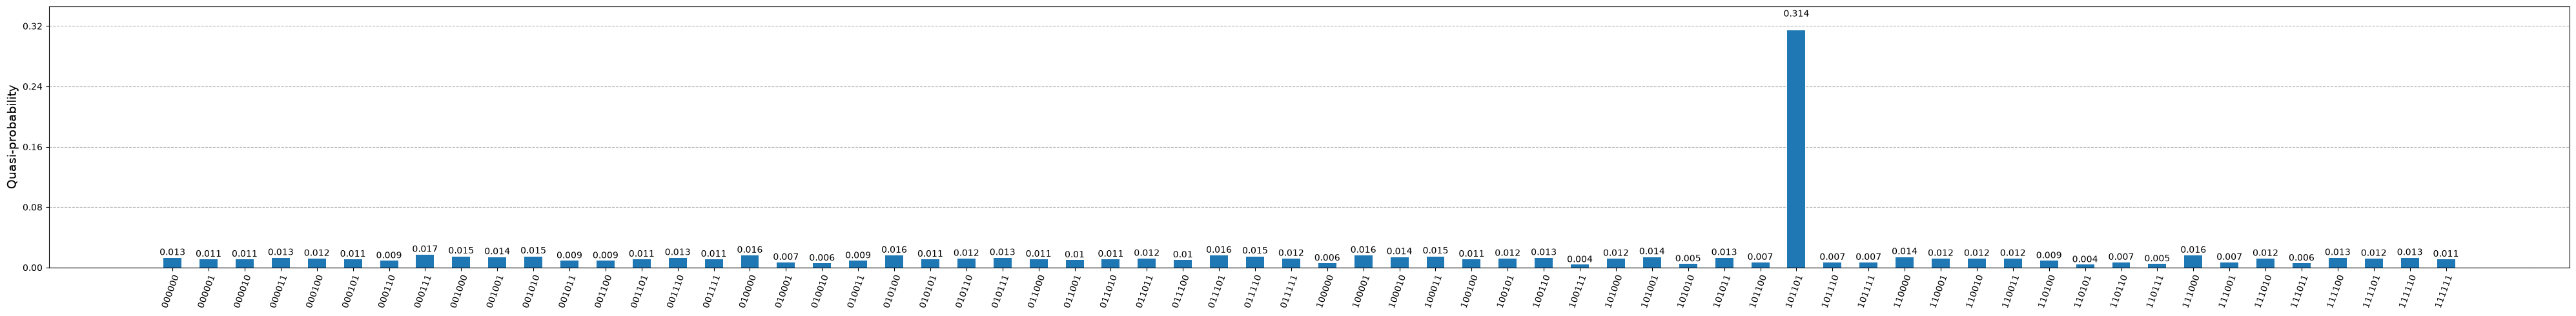

In [35]:
# Retrieve results from the primitive pub result
result = job.result()
dist = result[0].data.meas.get_counts()

plot_distribution(dist, figsize=(40, 5))